<a href="https://colab.research.google.com/github/Mmdata1111/cyclistic-bike-share-analysis-2020/blob/main/oil_market_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# U.S. Oil Prices, Rig Activity, and State Production Analysis (2000–2024)

## Objective
This project analyzes how oil prices, drilling activity, and state-level crude oil production changed from 2000 to 2024. The goal is to understand how market conditions influenced drilling behavior and production growth during major industry cycles, including the shale boom, the 2008 crash, the COVID-19 downturn, and the recovery period.

## Data Sources
- Baker Hughes US rig count data
- EIA WTI oil price data
- EIA state crude oil production data

In [ ]:
print("Energy project started")

Energy project started


In [ ]:
import pandas as pd
import numpy as np

## Rig Count Data Cleaning

This section loads the Baker Hughes US Oil & Gas Split data, keeps the total rig count, filters the timeframe to 2000–2024, and converts weekly rig counts to monthly averages for comparison with price and production data.

In [ ]:
rigs = pd.read_excel(
    "baker_hughes_rig_count.xlsx",
    sheet_name="US Oil & Gas Split",
    skiprows=6
)
rigs.head()


,Date,Oil,Gas,Misc,Total,% Oil,% Gas
0,1987-07-17,559,337,26,922,0.606291,0.365510
1,1987-07-24,565,331,21,917,0.616140,0.360960
2,1987-07-31,605,346,22,973,0.621788,0.355601
3,1987-08-07,613,349,21,983,0.623601,0.355036
4,1987-08-14,620,352,26,998,0.621242,0.352705


In [ ]:
rigs = rigs[["Date", "Total"]].copy()
rigs.columns = ["date", "rig_count"]

rigs.head()

,date,rig_count
0,1987-07-17,922
1,1987-07-24,917
2,1987-07-31,973
3,1987-08-07,983
4,1987-08-14,998


In [ ]:
rigs["date"] = pd.to_datetime(rigs["date"])

In [ ]:
rigs = rigs[(rigs["date"] >= "2000-01-01") & (rigs["date"] <= "2024-12-31")]

rigs.head()

,date,rig_count
651,2000-01-07,786
652,2000-01-14,781
653,2000-01-21,777
654,2000-01-28,755
655,2000-02-04,757


In [ ]:
rigs["month"] = rigs["date"].dt.to_period("M")

rigs_monthly = rigs.groupby("month")["rig_count"].mean().reset_index()

rigs_monthly["month"] = rigs_monthly["month"].astype(str)

rigs_monthly.head()

,month,rig_count
0,2000-01,774.75
1,2000-02,763.00
2,2000-03,773.00
3,2000-04,796.75
4,2000-05,844.00


**## WTI Oil Price Data Cleaning**

This section loads the EIA WTI monthly oil price series, removes metadata rows, standardizes column names, filters the study period to 2000–2024, and creates a monthly key for merging with the rig count and production datasets.

In [ ]:
price = pd.read_excel(
    "wti_oil_price_monthly.xlsx",
    sheet_name="Data 1"
)

price.head()

,Back to Contents,"Data 1: Cushing, OK WTI Spot Price FOB (Dollars per Barrel)"
0,Sourcekey,RWTC
1,Date,"Cushing, OK WTI Spot Price FOB (Dollars per Ba..."
2,1986-01-15 00:00:00,22.93
3,1986-02-15 00:00:00,15.46
4,1986-03-15 00:00:00,12.61


In [ ]:
price = pd.read_excel(
    "wti_oil_price_monthly.xlsx",
    sheet_name="Data 1",
    skiprows=2
)

price.head()

,Date,"Cushing, OK WTI Spot Price FOB (Dollars per Barrel)"
0,1986-01-15,22.93
1,1986-02-15,15.46
2,1986-03-15,12.61
3,1986-04-15,12.84
4,1986-05-15,15.38


In [ ]:
price = price.copy()
price.columns = ["date", "oil_price"]

price["date"] = pd.to_datetime(price["date"])
price["oil_price"] = pd.to_numeric(price["oil_price"], errors="coerce")

price.head()

,date,oil_price
0,1986-01-15,22.93
1,1986-02-15,15.46
2,1986-03-15,12.61
3,1986-04-15,12.84
4,1986-05-15,15.38


In [ ]:
price = price[(price["date"] >= "2000-01-01") & (price["date"] <= "2024-12-31")]
price.head()

,date,oil_price
168,2000-01-15,27.26
169,2000-02-15,29.37
170,2000-03-15,29.84
171,2000-04-15,25.72
172,2000-05-15,28.79


In [ ]:
price["month"] = price["date"].dt.to_period("M").astype(str)
price = price[["month", "oil_price"]]

price.head()

,month,oil_price
168,2000-01,27.26
169,2000-02,29.37
170,2000-03,29.84
171,2000-04,25.72
172,2000-05,28.79


### Saving Cleaned Datasets

After cleaning the rig count and WTI oil price datasets, we export them as CSV files. This allows the project to separate raw data from processed data and ensures that the cleaning steps do not need to be repeated in later analysis stages.

In [ ]:
import os
os.makedirs("data/processed", exist_ok=True)

In [ ]:
rigs_monthly.to_csv("data/processed/rigs_monthly_cleaned.csv", index=False)

In [ ]:
price.to_csv("data/processed/wti_price_monthly_cleaned.csv", index=False)

In [ ]:
from google.colab import files

files.download("data/processed/rigs_monthly_cleaned.csv")
files.download("data/processed/wti_price_monthly_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## State Crude Oil Production Data

This section loads and processes state-level crude oil production data from the U.S. Energy Information Administration (EIA).

States included in the analysis:

- Texas
- North Dakota
- New Mexico
- Alaska
- California

These states were selected because they represent the largest oil-producing regions in the United States and capture key developments in the modern oil market, including the shale boom.

### Data Processing Steps

For each state production dataset:

1. Load the EIA Excel workbook and select the `Data 1` sheet containing the production time series.
2. Skip metadata rows and extract the production data.
3. Standardize column names and convert values to numeric format.
4. Filter the analysis period to **2000–2024** to capture the modern oil market cycles.
5. Convert the date column into a **monthly key** to align with oil price and rig count datasets.
6. Export cleaned datasets for reproducibility.

The cleaned datasets are then merged with oil price and drilling activity data to build a unified analytical dataset for studying relationships between market conditions, drilling activity, and oil production.

In [ ]:
import os
os.listdir("data/processed")

['rigs_monthly_cleaned.csv', 'wti_price_monthly_cleaned.csv']

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving texas_oil_production_REAL.xlsx to texas_oil_production_REAL.xlsx


In [ ]:
import pandas as pd

In [ ]:
texas_check = pd.read_excel(
    "texas_oil_production_REAL.xlsx",
    sheet_name="Data 1",
    nrows=5
)

texas_check

,Back to Contents,Data 1: Texas Field Production of Crude Oil (Thousand Barrels)
0,Sourcekey,MCRFPTX1
1,Date,Texas Field Production of Crude Oil (Thousand ...
2,1981-01-15 00:00:00,80609
3,1981-02-15 00:00:00,72591
4,1981-03-15 00:00:00,80734


In [ ]:
texas = pd.read_excel(
    "texas_oil_production_REAL.xlsx",
    sheet_name="Data 1",
    skiprows=2
)

texas.columns = ["date", "texas_production"]

texas["date"] = pd.to_datetime(texas["date"])
texas["texas_production"] = pd.to_numeric(texas["texas_production"], errors="coerce")

texas = texas[(texas["date"] >= "2000-01-01") & (texas["date"] <= "2024-12-31")]

texas["month"] = texas["date"].dt.to_period("M").astype(str)

texas = texas[["month", "texas_production"]]

texas.head()

,month,texas_production
228,2000-01,38241
229,2000-02,36030
230,2000-03,38258
231,2000-04,36836
232,2000-05,37606


In [ ]:
import os
os.makedirs("data/processed", exist_ok=True)

texas.to_csv("data/processed/texas_production_cleaned.csv", index=False)

In [ ]:
rigs_monthly = pd.read_csv("data/processed/rigs_monthly_cleaned.csv")
price = pd.read_csv("data/processed/wti_price_monthly_cleaned.csv")

rigs_monthly.head(), price.head()

(     month  rig_count
 0  2000-01     774.75
 1  2000-02     763.00
 2  2000-03     773.00
 3  2000-04     796.75
 4  2000-05     844.00,
      month  oil_price
 0  2000-01      27.26
 1  2000-02      29.37
 2  2000-03      29.84
 3  2000-04      25.72
 4  2000-05      28.79)

## Building the Integrated Oil Market Dataset

After cleaning the rig activity, oil price, and state production datasets, we merge them into a single monthly dataset.

The final dataset contains:

- WTI oil price
- U.S. rig count
- State crude oil production for major producing regions

This integrated dataset enables analysis of how oil prices influence drilling activity and how drilling activity translates into production growth over time.

The dataset spans **January 2000 to December 2024**, covering several major industry cycles:

- Pre-shale era
- 2008 oil price crash
- U.S. shale boom
- 2014 oil price collapse
- COVID-19 demand shock
- Market recovery

In [ ]:
def load_state_production(file_name, output_col):
    df = pd.read_excel(file_name, sheet_name="Data 1", skiprows=2)
    df.columns = ["date", output_col]
    df["date"] = pd.to_datetime(df["date"])
    df[output_col] = pd.to_numeric(df[output_col], errors="coerce")
    df = df[(df["date"] >= "2000-01-01") & (df["date"] <= "2024-12-31")]
    df["month"] = df["date"].dt.to_period("M").astype(str)
    return df[["month", output_col]]

In [ ]:
north_dakota = load_state_production("north_dakota_oil_production.xlsx", "north_dakota_production")
new_mexico = load_state_production("new_mexico_oil_production.xlsx", "new_mexico_production")
alaska = load_state_production("alaska_oil_production.xlsx", "alaska_production")
california = load_state_production("california_oil_production.xlsx", "california_production")

north_dakota.head(), new_mexico.head()

(       month  north_dakota_production
 228  2000-01                     2766
 229  2000-02                     2627
 230  2000-03                     2818
 231  2000-04                     2722
 232  2000-05                     2804,
        month  new_mexico_production
 228  2000-01                   5846
 229  2000-02                   5503
 230  2000-03                   5802
 231  2000-04                   5649
 232  2000-05                   5841)

In [ ]:
north_dakota.to_csv("data/processed/north_dakota_production_cleaned.csv", index=False)
new_mexico.to_csv("data/processed/new_mexico_production_cleaned.csv", index=False)
alaska.to_csv("data/processed/alaska_production_cleaned.csv", index=False)
california.to_csv("data/processed/california_production_cleaned.csv", index=False)

In [ ]:
master = rigs_monthly.merge(price, on="month", how="inner")
master = master.merge(texas, on="month", how="inner")
master = master.merge(north_dakota, on="month", how="inner")
master = master.merge(new_mexico, on="month", how="inner")
master = master.merge(alaska, on="month", how="inner")
master = master.merge(california, on="month", how="inner")

master.head()

,month,rig_count,oil_price,texas_production,north_dakota_production,new_mexico_production,alaska_production,california_production
0,2000-01,774.75,27.26,38241,2766,5846,31751,22784
1,2000-02,763.00,29.37,36030,2627,5503,29906,21332
2,2000-03,773.00,29.84,38258,2818,5802,31395,22865
3,2000-04,796.75,25.72,36836,2722,5649,30241,22234
4,2000-05,844.00,28.79,37606,2804,5841,29934,23086


In [ ]:
master.to_csv("data/processed/us_oil_market_dataset_2000_2024.csv", index=False)

In [ ]:
from google.colab import files

files.download("data/processed/us_oil_market_dataset_2000_2024.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 291 entries, 0 to 290
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   month                    291 non-null    object 
 1   rig_count                291 non-null    float64
 2   oil_price                291 non-null    float64
 3   texas_production         291 non-null    int64  
 4   north_dakota_production  291 non-null    int64  
 5   new_mexico_production    291 non-null    int64  
 6   alaska_production        291 non-null    int64  
 7   california_production    291 non-null    int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 18.3+ KB


We first inspect the integrated dataset to understand its structure and summary statistics before performing exploratory analysis.

In [ ]:
master.describe()

,rig_count,oil_price,texas_production,north_dakota_production,new_mexico_production,alaska_production,california_production
count,291.000000,291.000000,291.000000,291.000000,291.000000,291.000000,291.000000
mean,1181.484708,63.265704,78695.237113,19149.350515,15187.694158,19357.161512,16509.697595
std,489.975905,25.610162,50017.336728,15114.950161,15354.130128,6158.615124,3546.099090
min,249.750000,16.550000,30189.000000,2306.000000,4602.000000,10857.000000,9275.000000
25%,791.000000,42.655000,33777.500000,3171.500000,5355.000000,14223.500000,13902.000000
50%,1077.250000,61.630000,53525.000000,16922.000000,6702.000000,16878.000000,16797.000000
75%,1718.000000,82.760000,121391.000000,34082.500000,18123.000000,24236.000000,18819.500000
max,2017.250000,133.880000,173059.000000,46443.000000,62369.000000,32416.000000,23253.000000


In [ ]:
master.corr(numeric_only=True)

,rig_count,oil_price,texas_production,north_dakota_production,new_mexico_production,alaska_production,california_production
rig_count,1.000000,0.536152,-0.558758,-0.402001,-0.579878,0.136529,0.381682
oil_price,0.536152,1.000000,0.149003,0.215624,0.174558,-0.533126,-0.405928
texas_production,-0.558758,0.149003,1.000000,0.935506,0.887337,-0.761619,-0.877016
north_dakota_production,-0.402001,0.215624,0.935506,1.000000,0.692347,-0.847813,-0.817504
new_mexico_production,-0.579878,0.174558,0.887337,0.692347,1.000000,-0.590063,-0.845487
alaska_production,0.136529,-0.533126,-0.761619,-0.847813,-0.590063,1.000000,0.874018
california_production,0.381682,-0.405928,-0.877016,-0.817504,-0.845487,0.874018,1.000000


## Correlation Analysis Between Oil Prices, Rig Activity, and State Production

To better understand relationships within the dataset, we compute the correlation matrix between oil prices, drilling activity, and state-level oil production.

The heatmap visualization provides a quick way to identify positive or negative relationships between variables:

- **Positive correlation** indicates that two variables tend to move in the same direction.
- **Negative correlation** indicates that two variables tend to move in opposite directions.

This analysis helps reveal how oil prices, drilling activity, and production levels interact over time and highlights structural relationships within the U.S. oil market.
Because the dataset covers a long time period (2000–2024), some correlations may also reflect structural changes in the industry, such as improvements in drilling efficiency during the shale boom.

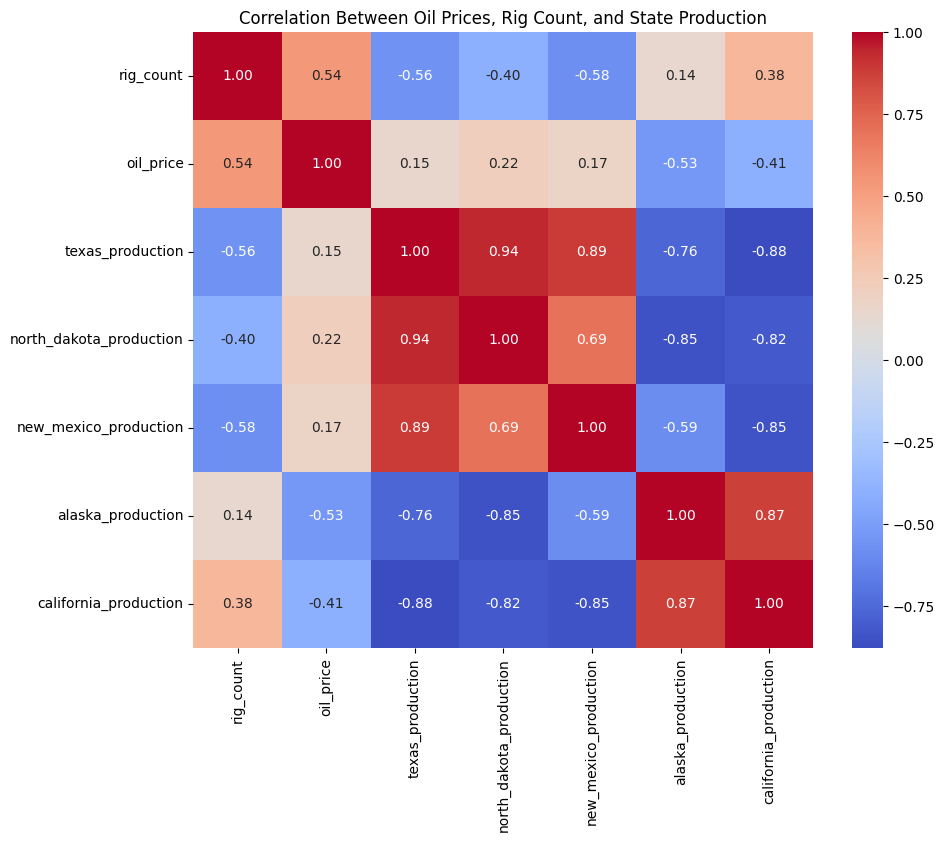

In [13]:
corr = master.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Correlation Between Oil Prices, Rig Count, and State Production")
plt.show()

In [ ]:
master.to_csv("us_oil_market_dataset_2000_2024.csv", index=False)

## Converting the Month Column to Datetime

The `month` column was initially stored as a text (object) data type after merging the datasets. To enable proper time-series analysis and visualization, the column is converted into a datetime format.

Converting the column to a datetime type allows Python to correctly interpret the data as chronological information, making it easier to generate time-series plots, extract yearly information, and perform temporal analysis across the dataset.

In [ ]:
master["month"] = pd.to_datetime(master["month"])
master.head()

,month,rig_count,oil_price,texas_production,north_dakota_production,new_mexico_production,alaska_production,california_production
0,2000-01-01,774.75,27.26,38241,2766,5846,31751,22784
1,2000-02-01,763.00,29.37,36030,2627,5503,29906,21332
2,2000-03-01,773.00,29.84,38258,2818,5802,31395,22865
3,2000-04-01,796.75,25.72,36836,2722,5649,30241,22234
4,2000-05-01,844.00,28.79,37606,2804,5841,29934,23086


## Oil Price vs Rig Activity

This chart compares monthly WTI oil prices with U.S. rig counts from 2000 to 2024. It helps evaluate whether higher oil prices are associated with increased drilling activity and whether major market shocks are reflected in rig deployment.

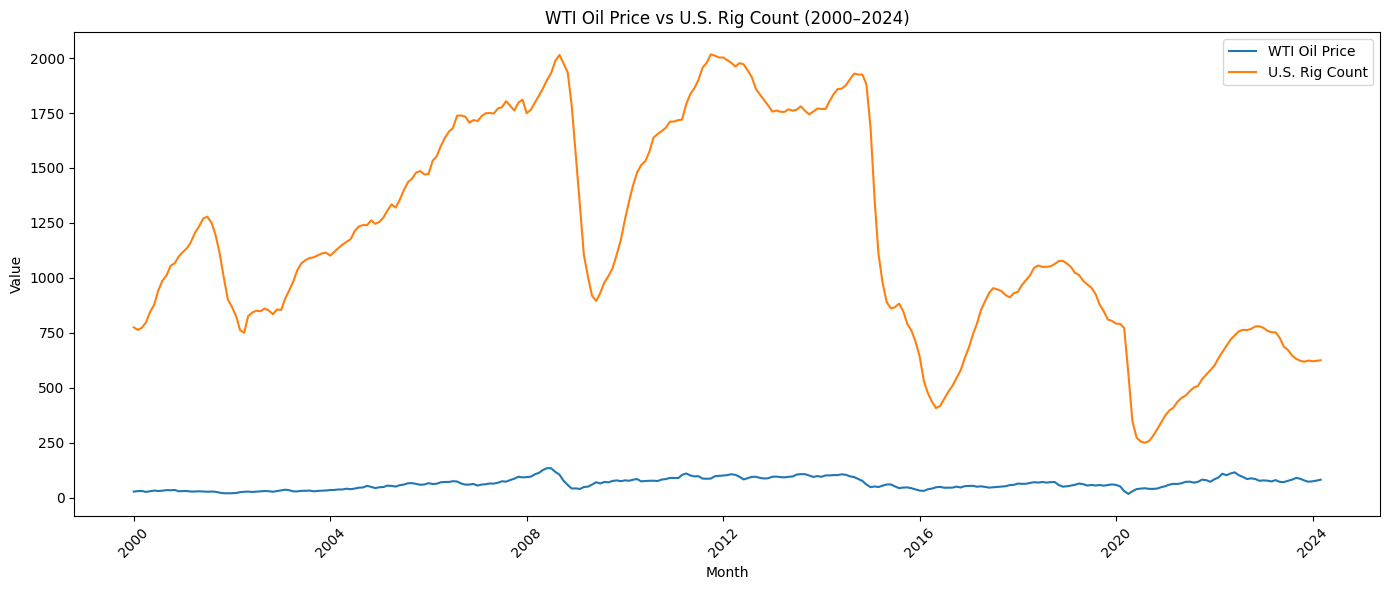

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(master["month"], master["oil_price"], label="WTI Oil Price")
plt.plot(master["month"], master["rig_count"], label="U.S. Rig Count")

plt.title("WTI Oil Price vs U.S. Rig Count (2000–2024)")
plt.xlabel("Month")
plt.ylabel("Value")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
from google.colab import files
uploaded = files.upload()

Saving us_oil_market_dataset_2000_2024.csv to us_oil_market_dataset_2000_2024.csv


In [9]:
master = pd.read_csv("us_oil_market_dataset_2000_2024.csv")
master["month"] = pd.to_datetime(master["month"])

master.head()

,month,rig_count,oil_price,texas_production,north_dakota_production,new_mexico_production,alaska_production,california_production
0,2000-01-01,774.75,27.26,38241,2766,5846,31751,22784
1,2000-02-01,763.00,29.37,36030,2627,5503,29906,21332
2,2000-03-01,773.00,29.84,38258,2818,5802,31395,22865
3,2000-04-01,796.75,25.72,36836,2722,5649,30241,22234
4,2000-05-01,844.00,28.79,37606,2804,5841,29934,23086


In [10]:
master["month"] = pd.to_datetime(master["month"])
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 291 entries, 0 to 290
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   month                    291 non-null    datetime64[ns]
 1   rig_count                291 non-null    float64       
 2   oil_price                291 non-null    float64       
 3   texas_production         291 non-null    int64         
 4   north_dakota_production  291 non-null    int64         
 5   new_mexico_production    291 non-null    int64         
 6   alaska_production        291 non-null    int64         
 7   california_production    291 non-null    int64         
dtypes: datetime64[ns](1), float64(2), int64(5)
memory usage: 18.3 KB


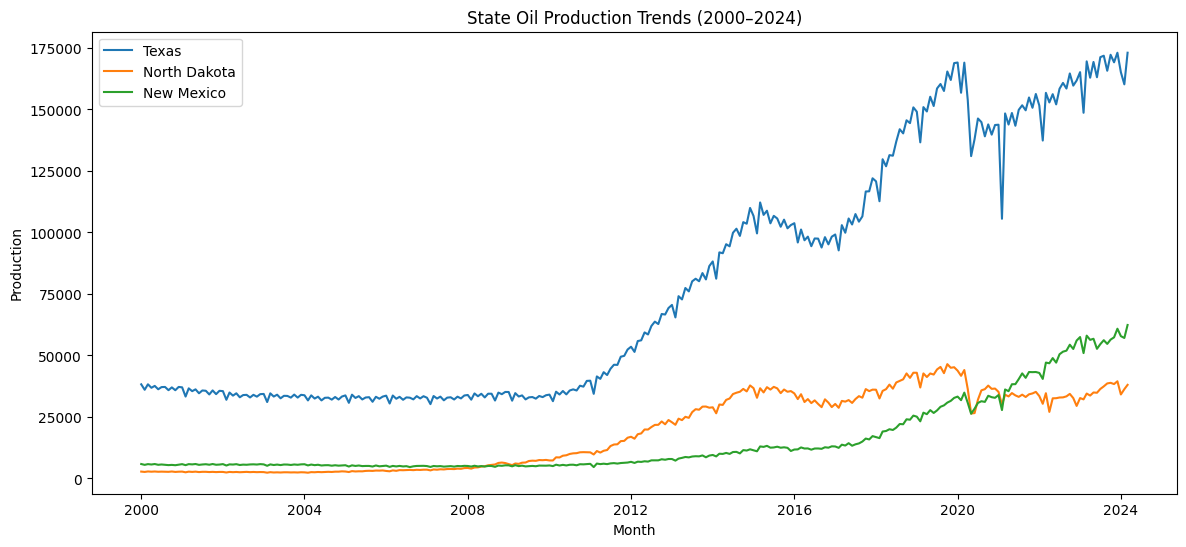

In [11]:
plt.figure(figsize=(14,6))

plt.plot(master["month"], master["texas_production"], label="Texas")
plt.plot(master["month"], master["north_dakota_production"], label="North Dakota")
plt.plot(master["month"], master["new_mexico_production"], label="New Mexico")

plt.title("State Oil Production Trends (2000–2024)")
plt.xlabel("Month")
plt.ylabel("Production")
plt.legend()
plt.show()

### State Production Trends Analysis

This visualization highlights production trends across major U.S. oil-producing states from 2000 to 2024. Texas remains the dominant producer throughout the period, maintaining a consistently high production level.

North Dakota and New Mexico exhibit significant production growth beginning in the early 2010s, corresponding with the expansion of shale drilling technologies. New Mexico, in particular, shows strong acceleration in later years, reflecting increased activity in the Permian Basin.

These trends suggest that advancements in drilling and completion technologies played a major role in shifting production dynamics across U.S. oil-producing regions.

Additionally, the divergence in production growth indicates that regional geology, infrastructure investment, and technological adoption significantly influenced output expansion across states.

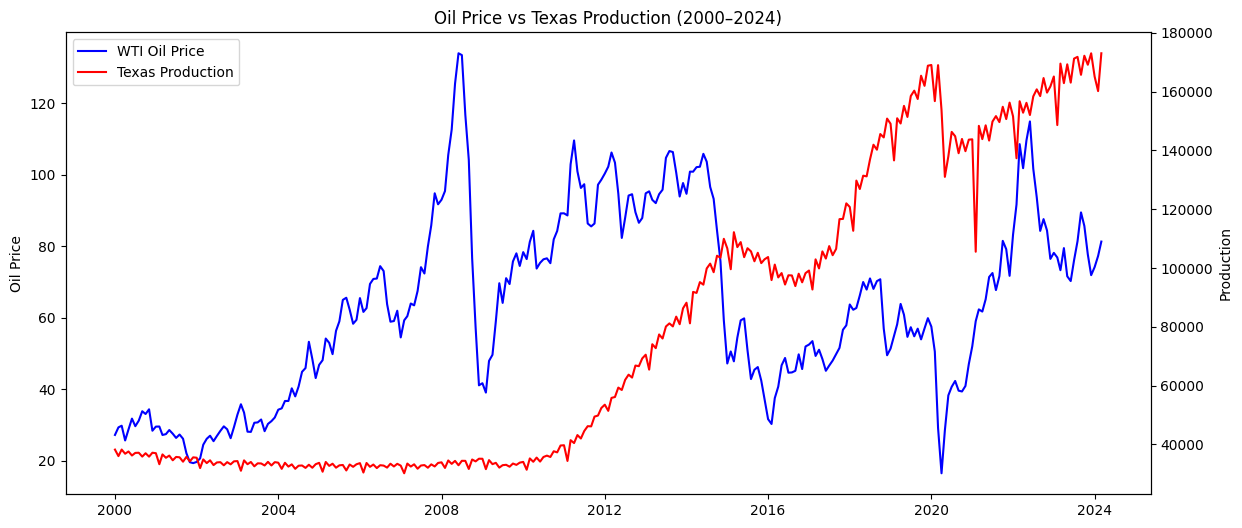

In [20]:
fig, ax1 = plt.subplots(figsize=(14,6))

# Oil price (left axis)
ax1.plot(master["month"], master["oil_price"], label="WTI Oil Price", color="blue")
ax1.set_ylabel("Oil Price")

# Production (right axis)
ax2 = ax1.twinx()
ax2.plot(master["month"], master["texas_production"], label="Texas Production", color="red")
ax2.set_ylabel("Production")

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

plt.legend(lines_1 + lines_2, labels_1 + labels_2)

plt.title("Oil Price vs Texas Production (2000–2024)")
plt.show()

### Oil Price vs Production Analysis

This chart compares WTI oil prices with Texas crude oil production over time.


 While oil prices show significant volatility—especially during major events such as the 2008 financial crisis and the 2020 COVID-19 downturn—Texas production follows a more stable upward trajectory.

This indicates that production is not solely driven by short-term price fluctuations. Instead, advancements in drilling technology, operational efficiency, and long-term investment strategies have enabled sustained production growth even during periods of lower oil prices.

This suggests a structural shift in the oil industry, where production has become more resilient to price volatility over time.

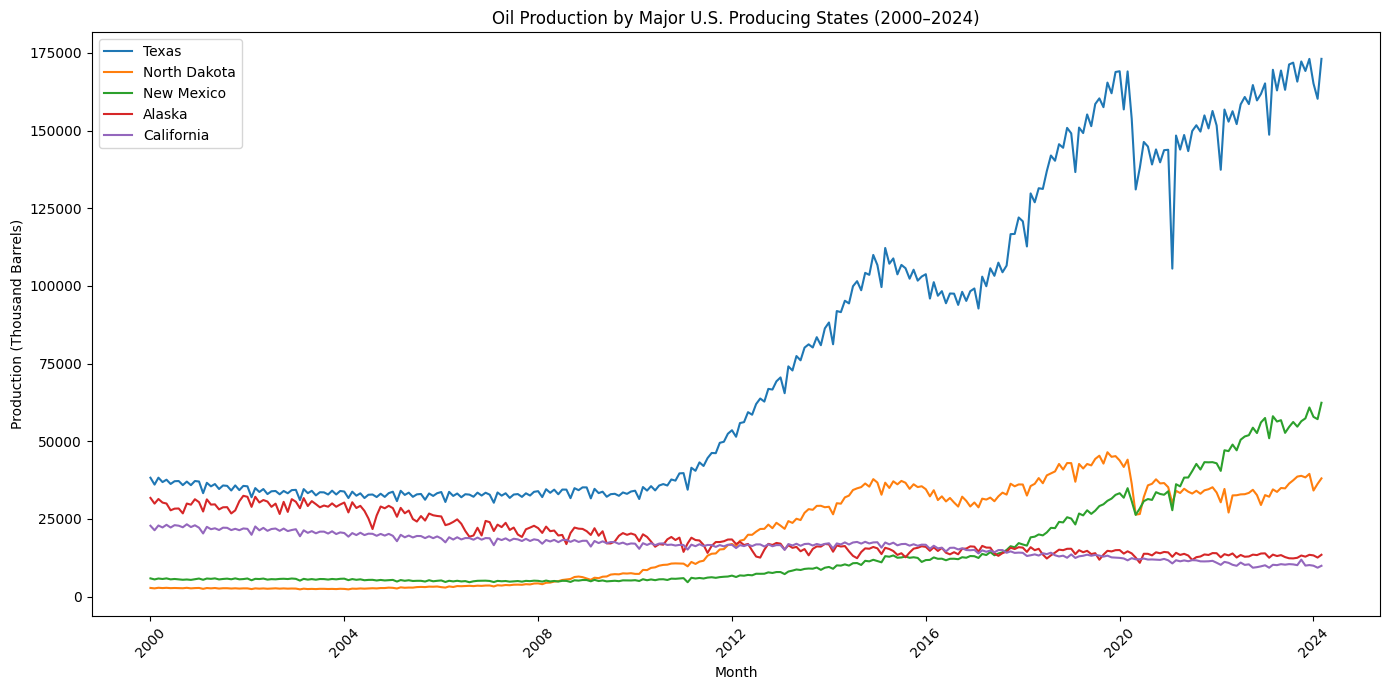

In [21]:
plt.figure(figsize=(14,7))

plt.plot(master["month"], master["texas_production"], label="Texas")
plt.plot(master["month"], master["north_dakota_production"], label="North Dakota")
plt.plot(master["month"], master["new_mexico_production"], label="New Mexico")
plt.plot(master["month"], master["alaska_production"], label="Alaska")
plt.plot(master["month"], master["california_production"], label="California")

plt.title("Oil Production by Major U.S. Producing States (2000–2024)")
plt.xlabel("Month")
plt.ylabel("Production (Thousand Barrels)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## State Production Comparison

This chart compares oil production across major producing states. It highlights the geographic concentration of U.S. production growth and helps distinguish shale-driven growth states from mature or declining production regions.

### Key Observations

Texas remains the dominant oil-producing state throughout the period, showing consistent growth and reinforcing its central role in U.S. oil supply.

North Dakota exhibits a sharp production increase beginning in the early 2010s, reflecting the rapid expansion of the Bakken shale formation during the shale boom.

New Mexico shows strong and accelerating growth in later years, driven by increased development in the Permian Basin, making it one of the fastest-growing production regions.

In contrast, Alaska and California display relatively flat or declining production trends, indicating mature fields and limited growth compared to shale-driven regions.

Overall, this comparison highlights that modern U.S. oil production growth has been heavily concentrated in shale-rich states, driven by technological advancements and resource development in specific geographic regions.

In [31]:
from google.colab import files

files.download("correlation_heatmap.png")
files.download("oil_price_vs_rig_count.png")
files.download("production_trends_shale_states.png")
files.download("oil_price_vs_texas_production.png")
files.download("state_production_comparison.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
master["year"] = master["month"].dt.year

yearly = master.groupby("year", as_index=False).agg({
    "oil_price": "mean",
    "rig_count": "mean",
    "texas_production": "mean",
    "north_dakota_production": "mean",
    "new_mexico_production": "mean",
    "alaska_production": "mean",
    "california_production": "mean"
})

yearly.head()

,year,oil_price,rig_count,texas_production,north_dakota_production,new_mexico_production,alaska_production,california_production
0,2000,30.300833,915.595833,36949.750000,2726.583333,5599.833333,29599.916667,22594.333333
1,2001,25.947500,1155.162500,35358.083333,2640.916667,5666.750000,29284.250000,21721.916667
2,2002,26.115000,831.058333,33814.666667,2566.833333,5630.083333,29948.333333,21491.666667
3,2003,31.120833,1031.441667,33388.666667,2450.750000,5549.166667,29633.416667,20674.416667
4,2004,41.443333,1189.970833,32726.250000,2596.000000,5376.416667,27703.500000,20011.583333


### Early Trends from Yearly Aggregation

The yearly aggregated data highlights baseline conditions in the early 2000s before the shale boom. During this period, oil prices remained relatively low to moderate, and production levels in key states such as Texas showed slight declines.

North Dakota and New Mexico production remained relatively low, indicating limited development prior to the expansion of shale technologies. In contrast, Alaska and California display gradual declines, reflecting mature oil fields with limited growth potential.

These early trends provide a useful baseline for understanding how production dynamics shift in later years with the introduction of shale drilling.

In [40]:
yearly.tail()

,year,oil_price,rig_count,texas_production,north_dakota_production,new_mexico_production,alaska_production,california_production
20,2020,39.227500,436.045833,147931.250000,36129.666667,31484.250000,13656.583333,12043.500000
21,2021,67.987500,475.116667,145539.083333,33764.916667,38625.166667,13304.083333,11428.666667
22,2022,94.786667,721.041667,155881.416667,32189.500000,49175.500000,13302.250000,10259.916667
23,2023,77.635833,688.608333,166824.000000,35979.333333,56022.500000,12956.250000,10265.416667
24,2024,77.560000,622.500000,166129.666667,36143.000000,59095.666667,13074.333333,9700.333333


### Recent Trends (2020–2024)

Recent data highlights a significant shift in the U.S. oil industry. Despite a sharp decline in oil prices and drilling activity in 2020 due to the COVID-19 pandemic, production—particularly in Texas and New Mexico—remains strong and continues to grow in subsequent years.

Notably, rig counts recover only partially and remain below historical peaks, while production levels reach new highs. This indicates substantial improvements in drilling efficiency and productivity, allowing operators to produce more with fewer rigs.

New Mexico emerges as one of the fastest-growing production regions, reflecting increased development in the Permian Basin. In contrast, Alaska and California continue to show declining production trends, reinforcing their status as mature oil-producing regions.

These patterns further support the conclusion that modern U.S. oil production is increasingly driven by technological advancement and operational efficiency rather than purely by drilling intensity or short-term price fluctuations.

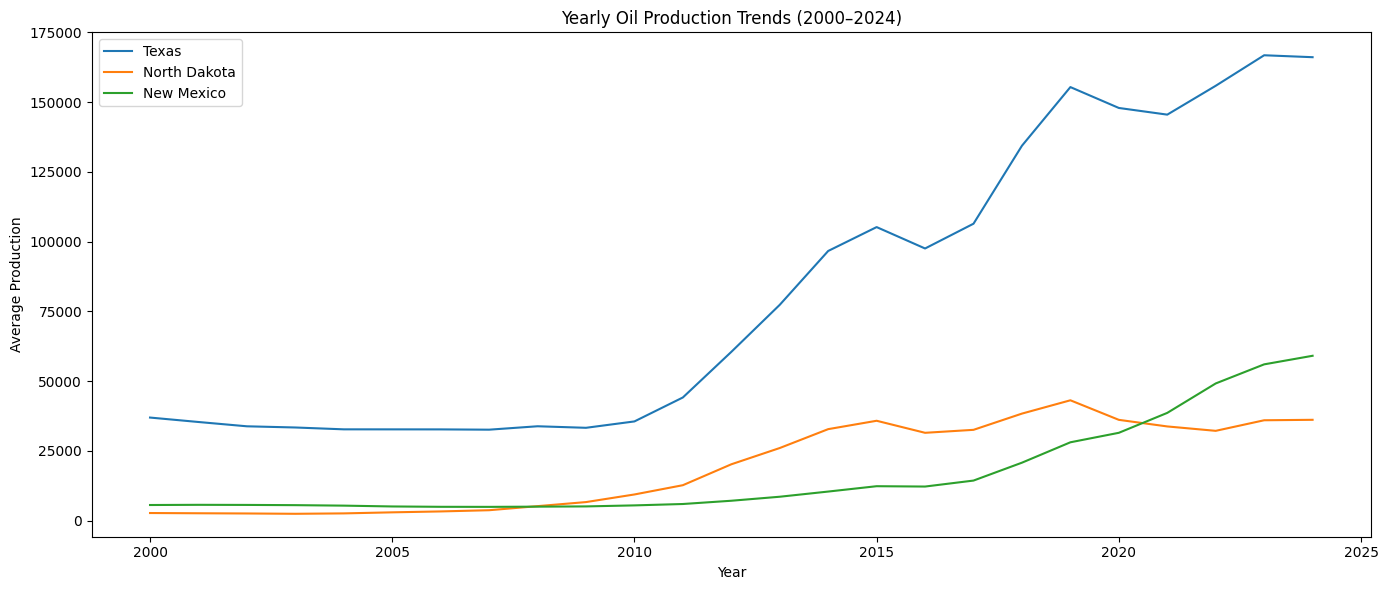

In [41]:
fig, ax = plt.subplots(figsize=(14,6))

ax.plot(yearly["year"], yearly["texas_production"], label="Texas")
ax.plot(yearly["year"], yearly["north_dakota_production"], label="North Dakota")
ax.plot(yearly["year"], yearly["new_mexico_production"], label="New Mexico")

ax.set_title("Yearly Oil Production Trends (2000–2024)")
ax.set_xlabel("Year")
ax.set_ylabel("Average Production")
ax.legend()

fig.tight_layout()
fig.savefig("yearly_production_trends.png", dpi=300, bbox_inches="tight")

plt.show()

### Yearly Production Trends

This chart presents yearly average production levels to highlight long-term trends and reduce short-term volatility seen in monthly data.

The visualization clearly shows the rapid growth of Texas, North Dakota, and New Mexico production following the shale boom. Compared to monthly fluctuations, the yearly trend provides a clearer view of sustained production growth and structural changes in the industry.

This reinforces the observation that U.S. oil production growth has been concentrated in key shale-producing regions over time.

In [42]:
from google.colab import files

files.download("yearly_production_trends.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [43]:
master["rig_lag_3"] = master["rig_count"].shift(3)
master["rig_lag_6"] = master["rig_count"].shift(6)

master[["rig_count", "rig_lag_3", "rig_lag_6", "texas_production"]].corr()

,rig_count,rig_lag_3,rig_lag_6,texas_production
rig_count,1.000000,0.956736,0.869999,-0.558758
rig_lag_3,0.956736,1.000000,0.956121,-0.529221
rig_lag_6,0.869999,0.956121,1.000000,-0.503216
texas_production,-0.558758,-0.529221,-0.503216,1.000000


### Lag and Structural Effects in Drilling and Production

A simple lag analysis was performed to evaluate whether increases in drilling activity lead to higher production with a delay. However, the correlation results show a negative relationship between rig counts and production, even when lagged variables are introduced.

This counterintuitive result reflects a structural transformation in the oil industry rather than a true inverse relationship. Over the study period, technological advancements—particularly during the shale boom—significantly improved drilling efficiency.

As a result, production increased substantially even as rig counts declined, masking the short-term lag relationship between drilling and output.

This indicates that long-term efficiency gains have a stronger impact on production than short-term changes in drilling activity, making simple lag-based correlations less effective for capturing true operational dynamics.

## Final Insights

This analysis examined the relationship between oil prices, drilling activity, and state-level crude oil production in the United States from 2000 to 2024.

The correlation analysis indicates a strong relationship between oil prices and drilling activity, where higher oil prices generally lead to increased rig deployment. However, the relationship between oil prices and production is less direct.

Time-series analysis shows that oil prices are highly volatile, influenced by major global events such as the 2008 financial crisis and the 2020 COVID-19 downturn. In contrast, production—particularly in Texas, North Dakota, and New Mexico—has demonstrated sustained long-term growth.

A lag analysis was conducted to evaluate whether increases in drilling activity lead to higher production with a delay. While production is expected to follow drilling activity over time, the results show a weak and even negative correlation between rig counts and production when lagged variables are introduced.

This counterintuitive result reflects a structural transformation in the oil industry rather than a true inverse relationship. Over the study period, technological advancements—particularly during the shale boom—significantly improved drilling efficiency, allowing operators to produce more with fewer rigs.

The comparison between oil prices and production further confirms this shift. Production levels continue to rise even during periods of price volatility and reduced drilling activity, indicating that technological advancements and operational efficiency have significantly improved productivity.

State-level analysis highlights that modern U.S. oil production growth is geographically concentrated in shale-rich regions. Texas remains the dominant producer, while New Mexico and North Dakota show rapid growth driven by the development of the Permian and Bakken basins. In contrast, Alaska and California exhibit stable or declining production, reflecting mature oil fields with limited expansion potential.

Yearly aggregated trends further reinforce these findings by reducing short-term noise and clearly illustrating long-term industry transformation. Despite lower rig counts in recent years, production has reached record highs, demonstrating that fewer rigs are required to achieve higher output.

Overall, the U.S. oil industry has evolved from a price-driven system to a more efficiency-driven model. Technological innovation, resource optimization, and strategic investment have enabled sustained production growth, even in the face of market volatility.